<a href="https://colab.research.google.com/github/gyatun/bank_loan_approval_pattern/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("loanapproval.csv")

In [ ]:
print(df)

     applicant_id  age  gender marital_status  annual_income  loan_amount  \
0               1   59    Male       Divorced         100073         7169   
1               2   49    Male        Married         112197        23556   
2               3   35    Male       Divorced          84429        27052   
3               4   63  Female         Single         124195        11313   
4               5   28  Female        Married          81627        13315   
..            ...  ...     ...            ...            ...          ...   
995           996   53  Female        Married         135598         6014   
996           997   22    Male         Single         139028        15103   
997           998   34  Female        Married         147517        21986   
998           999   60  Female       Divorced          73161        49781   
999          1000   60  Female         Single         141316        35471   

     credit_score  num_dependents  existing_loans_count employment_status  

In [ ]:
print(df.head())

   applicant_id  age  gender marital_status  annual_income  loan_amount  \
0             1   59    Male       Divorced         100073         7169   
1             2   49    Male        Married         112197        23556   
2             3   35    Male       Divorced          84429        27052   
3             4   63  Female         Single         124195        11313   
4             5   28  Female        Married          81627        13315   

   credit_score  num_dependents  existing_loans_count employment_status  \
0           793               1                     1        Unemployed   
1           789               0                     2          Employed   
2           372               1                     4        Unemployed   
3           808               3                     4     Self-employed   
4           689               0                     1        Unemployed   

   loan_approved  
0              1  
1              1  
2              0  
3              1  
4  

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB
None


In [ ]:
print(df.describe())

       applicant_id          age  annual_income   loan_amount  credit_score  \
count   1000.000000  1000.000000    1000.000000   1000.000000   1000.000000   
mean     500.500000    42.515000   81972.972000  27244.866000    576.125000   
std      288.819436    12.611059   37547.255418  12822.752877    155.921483   
min        1.000000    21.000000   20155.000000   5082.000000    300.000000   
25%      250.750000    32.000000   48913.250000  16587.500000    443.750000   
50%      500.500000    43.000000   82050.000000  27041.500000    573.500000   
75%      750.250000    53.000000  113556.000000  37939.250000    713.250000   
max     1000.000000    64.000000  149951.000000  49864.000000    849.000000   

       num_dependents  existing_loans_count  loan_approved  
count      1000.00000           1000.000000    1000.000000  
mean          1.97700              2.042000       0.729000  
std           1.41862              1.413589       0.444699  
min           0.00000              0.000000 

In [ ]:
df.isnull().sum()

,0
applicant_id,0
age,0
gender,0
marital_status,0
annual_income,0
loan_amount,0
credit_score,0
num_dependents,0
existing_loans_count,0
employment_status,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()

print("After Removing Duplicates:")%
print(df.duplicated().sum())

After Removing Duplicates:
0


In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

applicant_id: 0 outliers
age: 0 outliers
annual_income: 0 outliers
loan_amount: 0 outliers
credit_score: 0 outliers
num_dependents: 0 outliers
existing_loans_count: 0 outliers
loan_approved: 0 outliers


In [ ]:
df.to_csv("loan_data_cleaned.csv", index=False)

print("Dataset cleaned and saved!")

Dataset cleaned and saved!


Approval_check

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
pd.crosstab(
    df['gender'],
    df['loan_approved'],
    normalize='index'
)*100

loan_approved,0,1
gender,,
Female,27.941176,72.058824
Male,26.335878,73.664122


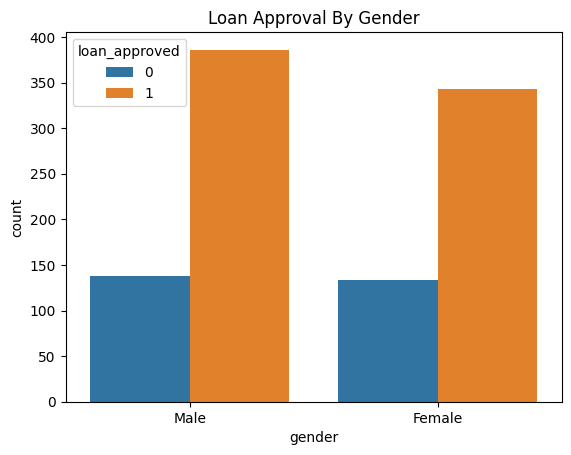

In [ ]:
sns.countplot(x='gender', hue='loan_approved', data = df)
plt.title("Loan Approval By Gender")
plt.show()

In [ ]:
df['Income_Group'] = pd.cut(
    df['annual_income'],
    bins =[20000,60000,90000,120000,150000],
    labels = ['Low','Medium','High','Very High']


)

In [ ]:
pd.crosstab(
    df['Income_Group'],
    df['loan_approved'],
    normalize='index'
)*100

loan_approved,0,1
Income_Group,,
Low,36.826347,63.173653
Medium,23.580786,76.419214
High,23.140496,76.859504
Very High,19.487179,80.512821


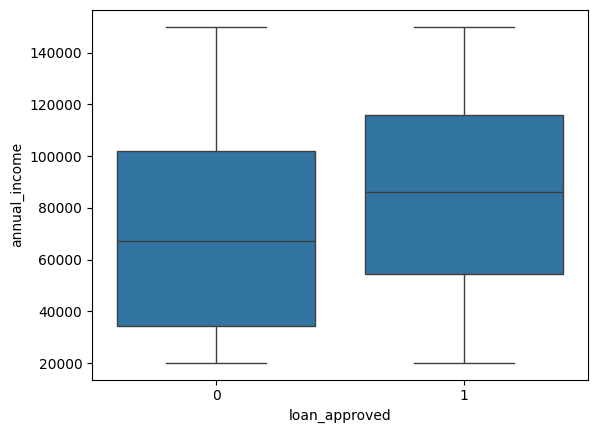

In [ ]:
sns.boxplot(x='loan_approved', y='annual_income', data=df)
plt.show()

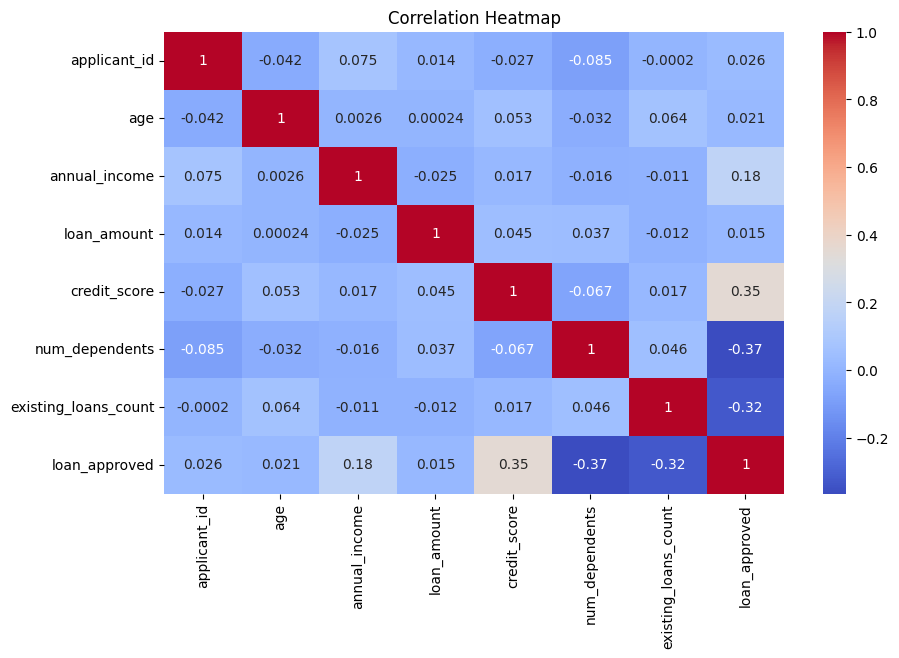

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()